# Neural Networks 


## Activate access to Google Drive 

In [44]:
# ##### If using Google Colab -- Uncomment following lines ######

# from google.colab import drive
# drive.mount('/content/gdrive')

## Import Files and Modules

In [45]:
import json
import random
import sys

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# from tensorflow.keras.datasets import mnist

import matplotlib.pyplot as plt


## Load MNIST Dataset

In [46]:
## Load the MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)  

## Renormalize the pixels. Note the Pixels values in MNIST range from 0 to 255 (8-bit grayscale: 0 = black, 255 = white), and dividing by 255 rescales them to the [0, 1] range.
X = X / 255.0 
## Convert the labels into integers.
y = y.astype(int)

## Split the data into train (80%) and test (20%) split 
X1, X_test, y1, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X1, y1, test_size=0.2, random_state=42)

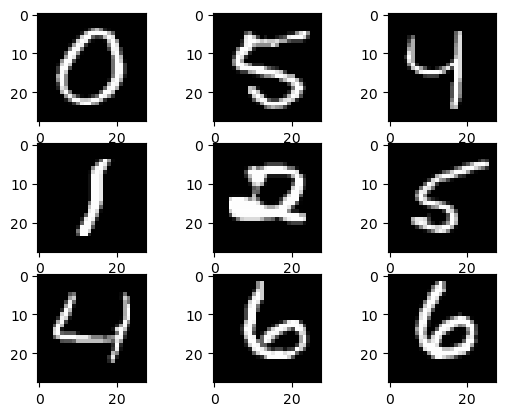

In [47]:
for i in range(9):  
    plt.subplot(330 + 1 + i)
    plt.imshow(np.reshape(X_train[i], (28,28)), cmap=plt.get_cmap('gray'))
plt.show()

## Loss function Calculator

In [48]:
class CrossEntropyCost:
    """Categorical cross-entropy, paired with softmax output."""
    @staticmethod
    def loss(a, y):
        return -np.sum(y * np.log(a + 1e-9*np.ones(np.shape(a)))) / np.shape(y)[0]
    # np.sum(np.nan_to_num(-y*np.log(a)-(1-y)*np.log(1-a)))

    @staticmethod
    def delta(a, y):
        return (a - y) / y.shape[0]      # softmax + CE shortcut


class MSECost:
    """Mean squared error, paired with softmax output here."""
    @staticmethod
    def loss(a, y):
        return np.sum((a - y)**2) / (2 * y.shape[0])

    @staticmethod
    def delta(a, y):
        return (a - y) / y.shape[0]      # assumes linear/identity output

## Neural Network module

In [49]:
class NeuralNet:

    def __init__(self, input_size = 784, ouptut_size = 10, layers=[64], lr=0.1, activation='relu', cost=CrossEntropyCost):
        """ Initialize the class:
            -- layers   : a list that contains the number of neurons in each hidden layer.
            -- lr       : Learning rate 
            -- cost     : Cost function used. 
        """
        self.layers = [input_size] + layers + [ouptut_size]
        # np.random.seed(42)
        self.num_layers = len(self.layers)
        self.activation_func = activation
        self.lr = lr
        self.cost = cost
        self.b = [np.zeros(y) for y in self.layers[1:] ]
        if activation == 'relu':
            self.W = [np.random.randn(x, y)*np.sqrt(2/x) for x, y in zip(self.layers[:-1], self.layers[1:]) ]
        else:
            self.W = [np.random.randn(x, y)*np.sqrt(2/x) for x, y in zip(self.layers[:-1], self.layers[1:]) ]    

 
    @staticmethod
    def _relu(z):
        """ The ReLU activation function"""
        return np.maximum(0, z)

    @staticmethod
    def _sigmoid(z):
        """The Sigmoid activation function."""
        return 1.0/(1.0+np.exp(-z))

    @staticmethod
    def softmax(z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    @staticmethod
    def out_val(y, classes = 10):
        out = np.zeros((np.size(y), classes))
        out[np.arange(y.size), y] = 1
        return out


    def _act_deriv(self,z):
        if self.activation_func == 'relu':
            return (z > 0).astype(z.dtype)
        elif self.activation_func == 'sigmoid':
            s = 1 / (1 + np.exp(-z))
            return s * (1 - s)
        else:
            return None
        

    def forward(self, x):
        self.Zs, self.activations = [], [x]
        for i in range(self.num_layers - 1):
            z = np.dot(self.activations[i], self.W[i]) + self.b[i]     #### z = x.W + b 
            self.Zs.append(z)
            if self.activation_func == 'relu':
                self.activations.append(self._relu(z) if i < len(self.W) - 1 else self.softmax(z))    #### a_i = ReLu(z)
            elif self.activation_func == 'sigmoid':    
                self.activations.append(self._sigmoid(z) if i < len(self.W) - 1 else self.softmax(z))   #### a_i = sigmoid(z)
            else:
                print("Activation function unknown")
                None
        return self.activations

    def backpropagation(self, yb):
        dz = (self.cost).delta(self.activations[-1], yb)
        for l in range(self.num_layers - 2, -1, -1):
            dW = np.dot(np.transpose(self.activations[l]),dz)
            db = dz.sum(axis = 0)
            if l > 0:
                zs = self.Zs[l-1]
                dz = np.dot(dz, np.transpose(self.W[l]))*self._act_deriv(zs) 
            self.W[l] -= self.lr*dW
            self.b[l] -= self.lr*db

    def SGD(self, X, y, X_val=None, y_val=None, epochs=20, batch_size=64):
        Y = self.out_val(y)
        loss, accuracy = [] , []
        for epoch in range(epochs):
            idx = np.random.permutation(X.shape[0])
            Xs, Ys = X[idx], Y[idx]
            epoch_loss = 0.0
            for i in range(0, Xs.shape[0], batch_size):
                yb = Ys[i:i+batch_size]
                out = self.forward(Xs[i:i+batch_size])
                epoch_loss += self.cost.loss(out[-1], yb) * yb.shape[0]
                self.backpropagation(yb)
            epoch_loss /= X.shape[0]
            # msg = f"epoch {epoch+1}: loss {epoch_loss:.4f}"
            if X_val is not None:
                acc = (self.predict(X_val) == y_val).mean()
                # msg += f" | val acc {acc:.4f}"
                accuracy.append(acc)
            loss.append(epoch_loss)
            # print(msg)
            print(f"epoch {epoch+1}: loss {loss[-1]:.4f}", 
              f"| val acc {accuracy[-1]:.4f}" if X_val is not None else "")
        return loss, accuracy

    def predict(self, X):
        return self.forward(X)[-1].argmax(axis=1)

    


In [ ]:
epoch = 20
lr = 0.1
layers = [64, 64]

classes = list(range(10))


In [ ]:

net = NeuralNet(input_size = 784, ouptut_size = 10, layers=layers, lr=lr, activation='relu', cost=CrossEntropyCost)

# print(net.layers)
for i in range(np.size(net.layers)-1):
    print(f"{i}th layer {net.layers[i]} Neurons")
    print("Dimension of Weight matrix W :", np.shape(net.W[i]))
    print("Dimension of Bias matrix b :",np.shape(net.b[i]))
    print()
# print(np.shape(net.W))
# print(np.shape(net.b))


epoch 1: loss 0.3746 | val acc 0.9337
epoch 2: loss 0.1799 | val acc 0.9518
epoch 3: loss 0.1339 | val acc 0.9548
epoch 4: loss 0.1076 | val acc 0.9637
epoch 5: loss 0.0923 | val acc 0.9636
epoch 6: loss 0.0784 | val acc 0.9591
epoch 7: loss 0.0687 | val acc 0.9693
epoch 8: loss 0.0595 | val acc 0.9684
epoch 9: loss 0.0532 | val acc 0.9671
epoch 10: loss 0.0472 | val acc 0.9696
epoch 11: loss 0.0424 | val acc 0.9721
epoch 12: loss 0.0370 | val acc 0.9704
epoch 13: loss 0.0323 | val acc 0.9716
epoch 14: loss 0.0289 | val acc 0.9685
epoch 15: loss 0.0268 | val acc 0.9735
epoch 16: loss 0.0227 | val acc 0.9712
epoch 17: loss 0.0197 | val acc 0.9730
epoch 18: loss 0.0185 | val acc 0.9719
epoch 19: loss 0.0145 | val acc 0.9721
epoch 20: loss 0.0122 | val acc 0.9710


In [ ]:

loss, accuracy = net.SGD(X_train, y_train, X_val, y_val, epochs=epoch)

0th layer 784 Neurons
Dimension of Weight matrix W : (784, 64)
Dimension of Bias matrix b : (64,)

1th layer 64 Neurons
Dimension of Weight matrix W : (64, 64)
Dimension of Bias matrix b : (64,)

2th layer 64 Neurons
Dimension of Weight matrix W : (64, 10)
Dimension of Bias matrix b : (10,)



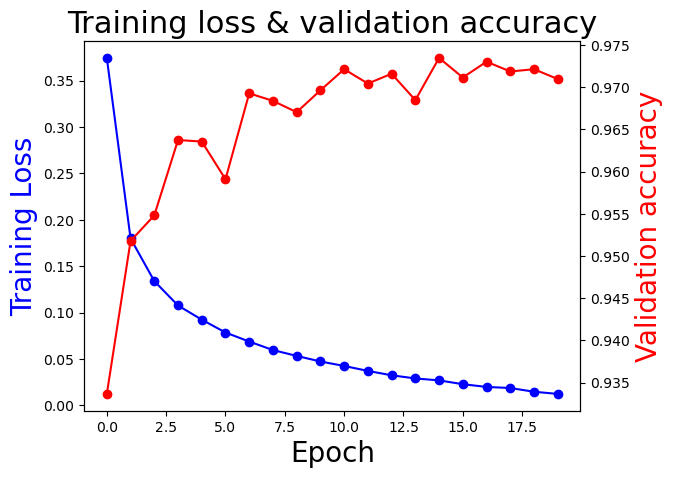

In [53]:
# === 1. Loss / accuracy curves ===
fig, ax1 = plt.subplots()
ax1.scatter(np.arange(epoch), loss, c ='b', label='train loss')
ax1.plot(loss, 'b-')
ax1.set_xlabel('Epoch', fontsize = 20); ax1.set_ylabel('Training Loss', color='b', fontsize = 20)
ax2 = ax1.twinx()
ax2.scatter(np.arange(epoch), accuracy, c = 'r', label='val acc')
ax2.plot(accuracy, 'r-')
ax2.set_ylabel('Validation accuracy', color='r',fontsize = 20)
plt.title('Training loss & validation accuracy', fontsize = 22)
plt.show()


428 misclassified out of 14000
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1343
           1       0.98      0.99      0.98      1600
           2       0.98      0.94      0.96      1380
           3       0.96      0.97      0.97      1433
           4       0.98      0.96      0.97      1295
           5       0.97      0.97      0.97      1273
           6       0.95      0.99      0.97      1396
           7       0.97      0.98      0.97      1503
           8       0.96      0.95      0.96      1357
           9       0.96      0.97      0.96      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



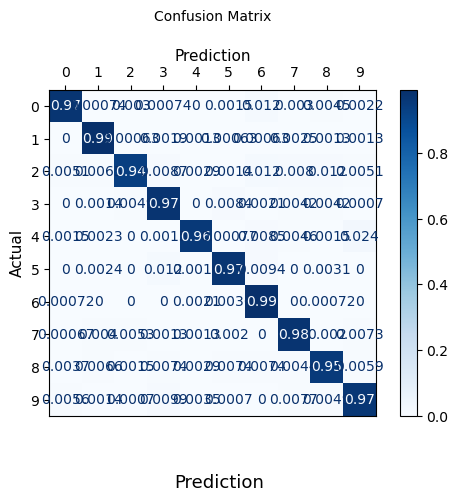

In [60]:
pred = net.predict(X_test)

# === Misclassified images ===
wrong = np.where(pred != y_test)[0]          # indices of mistakes
print(f"{len(wrong)} misclassified out of {len(y_test)}")

# === Confusion matrix ===

# cm = confusion_matrix(y_test, pred)

cm = confusion_matrix(y_test, pred, labels=classes)

cm = cm/np.sum(cm, axis=1, keepdims=True)

print(classification_report(y_test, pred, target_names=[str(c) for c in classes]))


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=10, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.show()

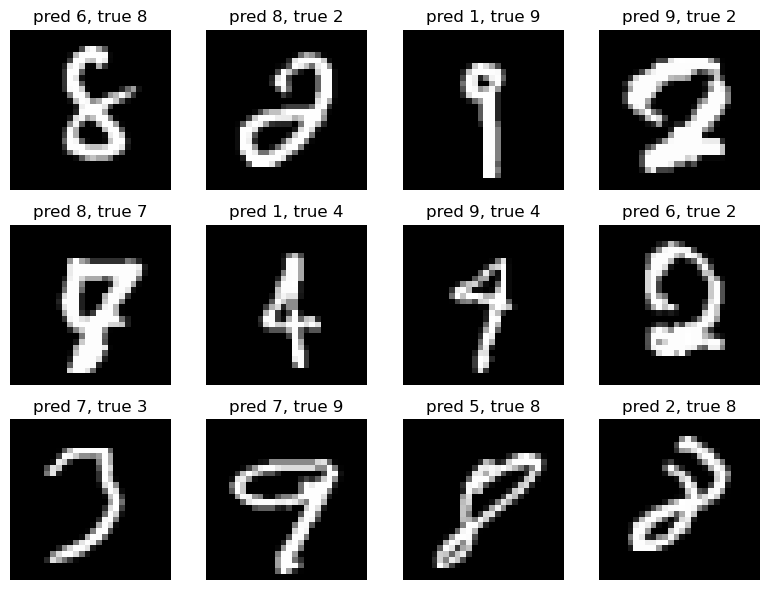

In [ ]:
n = min(12, len(wrong))
sample = np.random.choice(wrong, n, replace=False)
cols = 4; rows = int(np.ceil(n / cols))
plt.figure(figsize=(cols*2, rows*2))
for k, idx in enumerate(sample):
    plt.subplot(rows, cols, k+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"pred {pred[idx]}, true {y_test[idx]}", fontsize=12)
    plt.axis('off')
plt.tight_layout(); plt.show()